
# Impact of AI Learning Behavior on Student Academic Performance  
# AI 学习行为对学生学业表现的影响

## Final Bilingual Project Notebook | 最终双语项目 Notebook

This notebook is designed for the final course project and follows the allowed methods in the assignment.  
本 Notebook 面向课程期末项目，严格围绕作业允许的方法展开。

### Methods used | 使用的方法
**Category A**
- Facet Chart
- Linear Regression
- Logistic Regression

**Category B**
- Lasso Regression

### Business objective | 业务目标
This project examines how learning behavior and AI usage patterns are associated with student performance, identifies at-risk students, and extracts the most important variables for educational intervention.  
本项目分析学习行为与 AI 使用模式如何与学生成绩相关，识别高风险学生，并提炼最关键的干预变量，为教育管理决策提供支持。



## 1. Setup and package import | 环境配置与库导入

The following libraries are used for data processing, visualization, modeling, and evaluation.  
以下库将用于数据处理、可视化、建模与模型评估。


In [79]:

# -----------------------------
# 1. Import libraries | 导入所需库
# -----------------------------

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from IPython.display import display

# Machine learning related packages | 机器学习相关库
from sklearn.model_selection import train_test_split, cross_val_score, KFold, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression, LassoCV
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report,
    precision_recall_curve, average_precision_score
)
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Visualization style | 可视化风格
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.unicode_minus"] = False

print("Libraries imported successfully. | 库导入完成。")


Libraries imported successfully. | 库导入完成。



## 2. Load data | 读取数据

Make sure the CSV file is in the same folder as this notebook.  
请确保 CSV 数据文件与本 Notebook 位于同一文件夹下。


In [80]:

# -----------------------------
# 2. Load dataset | 读取数据集
# -----------------------------

import os

# Try notebook directory first, then /mnt/data as a fallback
# 优先尝试 Notebook 当前目录，其次尝试 /mnt/data 作为回退路径
candidate_paths = [
    "ai_impact_student_performance_dataset.csv",
    os.path.join("/mnt/data", "ai_impact_student_performance_dataset.csv")
]

data_path = None
for p in candidate_paths:
    if os.path.exists(p):
        data_path = p
        break

if data_path is None:
    raise FileNotFoundError("Could not find ai_impact_student_performance_dataset.csv | 未找到数据文件")

df = pd.read_csv(data_path)

print(f"Loaded file | 已加载文件: {data_path}")
print(f"Dataset shape | 数据集维度: {df.shape}")
display(df.head())


Loaded file | 已加载文件: ai_impact_student_performance_dataset.csv
Dataset shape | 数据集维度: (8000, 26)


,student_id,age,gender,grade_level,study_hours_per_day,uses_ai,ai_usage_time_minutes,ai_tools_used,ai_usage_purpose,ai_dependency_score,...,concept_understanding_score,study_consistency_index,improvement_rate,sleep_hours,social_media_hours,tutoring_hours,class_participation_score,final_score,passed,performance_category
0,1,20,Female,1st Year,2.5,1,170,NaN,Exam Prep,10,...,4,9.0,8.1,7.2,1.5,4.6,6,36.8,0,Low
1,2,17,Male,12th,3.4,1,123,NaN,Notes,4,...,8,8.5,13.8,7.6,5.1,2.7,6,65.5,1,Medium
2,3,24,Male,3rd Year,0.8,0,35,Copilot,Doubt Solving,8,...,7,2.1,39.1,5.7,0.2,4.0,3,66.3,1,Medium
3,4,21,Female,12th,4.4,0,45,ChatGPT+Gemini,Notes,3,...,5,6.7,25.2,8.2,4.2,2.9,2,69.5,1,Medium
4,5,18,Other,3rd Year,3.5,1,21,ChatGPT+Gemini,Coding,2,...,5,5.4,2.7,8.7,0.2,2.9,2,49.7,1,Low



## 3. Quick data audit | 快速数据审查

This section helps us understand the structure of the dataset before cleaning and modeling.  
这一部分用于在清洗与建模前，快速了解数据结构。


In [81]:

# -----------------------------
# 3. Quick audit | 快速审查
# -----------------------------

print("Column names | 字段名称:")
print(df.columns.tolist())

print("\nData types | 数据类型:")
display(df.dtypes.to_frame("dtype"))

print("\nMissing values | 缺失值统计:")
display(df.isna().sum().sort_values(ascending=False).to_frame("missing_count"))

print("\nDescriptive statistics | 描述性统计:")
display(df.describe(include="all").T)


Column names | 字段名称:
['student_id', 'age', 'gender', 'grade_level', 'study_hours_per_day', 'uses_ai', 'ai_usage_time_minutes', 'ai_tools_used', 'ai_usage_purpose', 'ai_dependency_score', 'ai_generated_content_percentage', 'ai_prompts_per_week', 'ai_ethics_score', 'last_exam_score', 'assignment_scores_avg', 'attendance_percentage', 'concept_understanding_score', 'study_consistency_index', 'improvement_rate', 'sleep_hours', 'social_media_hours', 'tutoring_hours', 'class_participation_score', 'final_score', 'passed', 'performance_category']

Data types | 数据类型:


,dtype
student_id,int64
age,int64
gender,object
grade_level,object
study_hours_per_day,float64
uses_ai,int64
ai_usage_time_minutes,int64
ai_tools_used,object
ai_usage_purpose,object
ai_dependency_score,int64



Missing values | 缺失值统计:


,missing_count
ai_tools_used,1362
ai_usage_purpose,1346
student_id,0
assignment_scores_avg,0
passed,0
final_score,0
class_participation_score,0
tutoring_hours,0
social_media_hours,0
sleep_hours,0



Descriptive statistics | 描述性统计:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
student_id,8000.0,NaN,NaN,NaN,4000.5,2309.54541,1.0,2000.75,4000.5,6000.25,8000.0
age,8000.0,NaN,NaN,NaN,18.96725,3.15316,14.0,16.0,19.0,22.0,24.0
gender,8000,3,Male,3908,NaN,NaN,NaN,NaN,NaN,NaN,NaN
grade_level,8000,6,1st Year,1356,NaN,NaN,NaN,NaN,NaN,NaN,NaN
study_hours_per_day,8000.0,NaN,NaN,NaN,3.286938,1.582171,0.5,1.9,3.3,4.6,6.0
uses_ai,8000.0,NaN,NaN,NaN,0.641,0.479737,0.0,0.0,1.0,1.0,1.0
ai_usage_time_minutes,8000.0,NaN,NaN,NaN,88.989875,52.184077,0.0,43.0,89.0,134.0,179.0
ai_tools_used,6638,5,ChatGPT+Gemini,1399,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ai_usage_purpose,6654,5,Exam Prep,1368,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ai_dependency_score,8000.0,NaN,NaN,NaN,5.515125,2.883064,1.0,3.0,6.0,8.0,10.0



## 4. Data preprocessing | 数据预处理

### Cleaning logic | 清洗逻辑
1. Fill missing categorical values with `"Unknown"`.  
   对类别变量缺失值填充 `"Unknown"`。
2. For students with `uses_ai = 0`, reset AI-related behavioral variables to zero and relabel AI categories as `"No AI"`.  
   对于 `uses_ai = 0` 的学生，将 AI 相关数值变量置零，并将 AI 类别变量统一标记为 `"No AI"`。
3. Create an intervention-oriented binary target variable `at_risk`.  
   构建面向干预场景的二元目标变量 `at_risk`。

### Why create `at_risk`? | 为什么构建 `at_risk`
A binary risk label makes the project more actionable for management.  
二元风险标签更适合管理层做预警和干预决策。

- `at_risk = 1` if `final_score < 50`
- `at_risk = 0` otherwise


In [82]:

# -----------------------------
# 4. Data preprocessing | 数据预处理
# -----------------------------

# Work on a copy so the raw data remains unchanged | 基于副本处理，避免修改原始数据
data = df.copy()

# Fill missing values in categorical columns | 填充类别变量缺失值
categorical_fill_cols = [
    "ai_tools_used", "ai_usage_purpose", "gender", "grade_level", "performance_category"
]
for col in categorical_fill_cols:
    data[col] = data[col].fillna("Unknown")

# For non-AI users, reset AI-related numeric variables to 0 | 对非 AI 使用者，将 AI 数值变量统一置零
non_ai_mask = data["uses_ai"] == 0
ai_numeric_cols = [
    "ai_usage_time_minutes", "ai_dependency_score",
    "ai_generated_content_percentage", "ai_prompts_per_week", "ai_ethics_score"
]
data.loc[non_ai_mask, ai_numeric_cols] = 0

# Also reset AI-related categories for non-AI users | 对非 AI 使用者重置 AI 类别字段
data.loc[non_ai_mask, "ai_tools_used"] = "No AI"
data.loc[non_ai_mask, "ai_usage_purpose"] = "No AI"

# Create binary at-risk flag | 构建高风险学生标签
data["at_risk"] = (data["final_score"] < 50).astype(int)

print("Preview after preprocessing | 预处理后数据预览:")
display(data.head())

print("At-risk distribution | 高风险学生分布:")
display(data["at_risk"].value_counts().to_frame("count"))


Preview after preprocessing | 预处理后数据预览:


,student_id,age,gender,grade_level,study_hours_per_day,uses_ai,ai_usage_time_minutes,ai_tools_used,ai_usage_purpose,ai_dependency_score,...,study_consistency_index,improvement_rate,sleep_hours,social_media_hours,tutoring_hours,class_participation_score,final_score,passed,performance_category,at_risk
0,1,20,Female,1st Year,2.5,1,170,Unknown,Exam Prep,10,...,9.0,8.1,7.2,1.5,4.6,6,36.8,0,Low,1
1,2,17,Male,12th,3.4,1,123,Unknown,Notes,4,...,8.5,13.8,7.6,5.1,2.7,6,65.5,1,Medium,0
2,3,24,Male,3rd Year,0.8,0,0,No AI,No AI,0,...,2.1,39.1,5.7,0.2,4.0,3,66.3,1,Medium,0
3,4,21,Female,12th,4.4,0,0,No AI,No AI,0,...,6.7,25.2,8.2,4.2,2.9,2,69.5,1,Medium,0
4,5,18,Other,3rd Year,3.5,1,21,ChatGPT+Gemini,Coding,2,...,5.4,2.7,8.7,0.2,2.9,2,49.7,1,Low,1


At-risk distribution | 高风险学生分布:


,count
at_risk,
0,5483
1,2517



## 5. Descriptive statistics | 描述性统计

A concise descriptive overview helps frame the business problem before modeling.  
在正式建模前，简要的描述性统计有助于建立业务背景。


In [83]:

# -----------------------------
# 5. Descriptive statistics | 描述性统计
# -----------------------------

numeric_summary_cols = [
    "study_hours_per_day", "attendance_percentage", "concept_understanding_score",
    "study_consistency_index", "sleep_hours", "social_media_hours",
    "ai_usage_time_minutes", "ai_dependency_score", "ai_generated_content_percentage",
    "final_score"
]

display(data[numeric_summary_cols].describe().T)

print("Pass rate | 通过率:")
display(data["passed"].value_counts(normalize=True).rename("proportion").to_frame())

print("Performance category distribution | 成绩等级分布:")
display(data["performance_category"].value_counts(normalize=True).rename("proportion").to_frame())

print("AI usage distribution | AI 使用分布:")
display(data["uses_ai"].value_counts(normalize=True).rename("proportion").to_frame())


,count,mean,std,min,25%,50%,75%,max
study_hours_per_day,8000.0,3.286938,1.582171,0.5,1.9,3.3,4.6,6.0
attendance_percentage,8000.0,69.852112,17.234339,40.0,54.8,70.0,84.6,100.0
concept_understanding_score,8000.0,5.484750,2.898546,1.0,3.0,5.0,8.0,10.0
study_consistency_index,8000.0,5.516450,2.586377,1.0,3.2,5.5,7.8,10.0
sleep_hours,8000.0,6.465025,1.435670,4.0,5.2,6.4,7.7,9.0
social_media_hours,8000.0,3.010600,1.744974,0.0,1.5,3.0,4.5,6.0
ai_usage_time_minutes,8000.0,56.823875,59.651900,0.0,0.0,38.0,108.0,179.0
ai_dependency_score,8000.0,3.548375,3.505274,0.0,0.0,3.0,7.0,10.0
ai_generated_content_percentage,8000.0,31.926875,33.560242,0.0,0.0,22.0,61.0,100.0
final_score,8000.0,56.811988,13.455724,12.7,47.3,56.9,66.2,95.8


Pass rate | 通过率:


,proportion
passed,
1,0.88925
0,0.11075


Performance category distribution | 成绩等级分布:


,proportion
performance_category,
Medium,0.588125
Low,0.317750
High,0.094125


AI usage distribution | AI 使用分布:


,proportion
uses_ai,
1,0.641
0,0.359



## 6. Visual analytics and exploratory data analysis | 可视化分析与探索性数据分析

This section adds rich visual evidence to make the data easier to interpret.  
这一部分通过更丰富的可视化，让数据特征和关系更加直观。

The charts below include:  
下列图表包括：
- Missing value chart | 缺失值图
- Distribution plots | 分布图
- Correlation heatmap | 相关性热力图
- Scatter plots | 散点图
- Box plots | 箱线图
- Bar charts | 柱状图
- Facet charts | 分面图


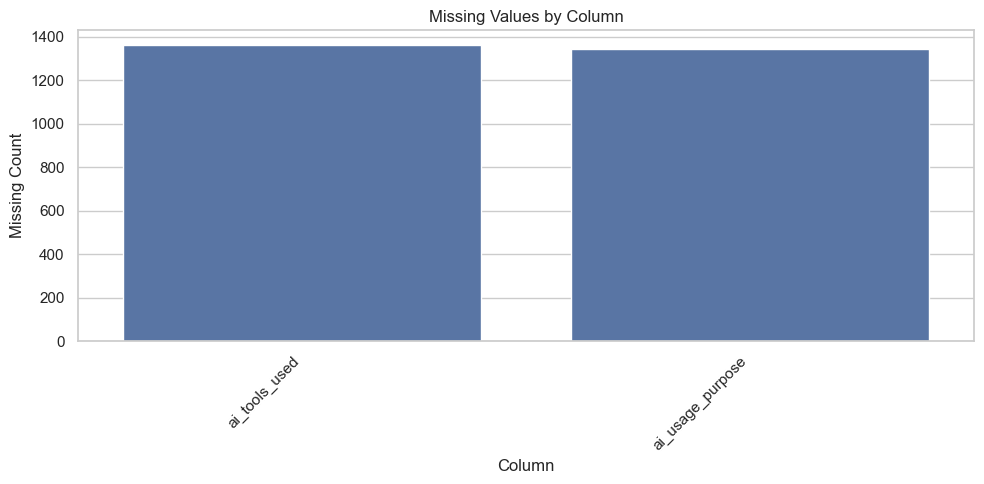

In [108]:

# -----------------------------
# 6.1 Missing values visualization | 缺失值可视化
# -----------------------------

missing_counts = df.isna().sum().sort_values(ascending=False)
missing_counts = missing_counts[missing_counts > 0]

if len(missing_counts) > 0:
    plt.figure(figsize=(10, 5))
    sns.barplot(x=missing_counts.index, y=missing_counts.values, color="C0")
    plt.xticks(rotation=45, ha="right")
    plt.title("Missing Values by Column")
    plt.xlabel("Column")
    plt.ylabel("Missing Count")
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found.")


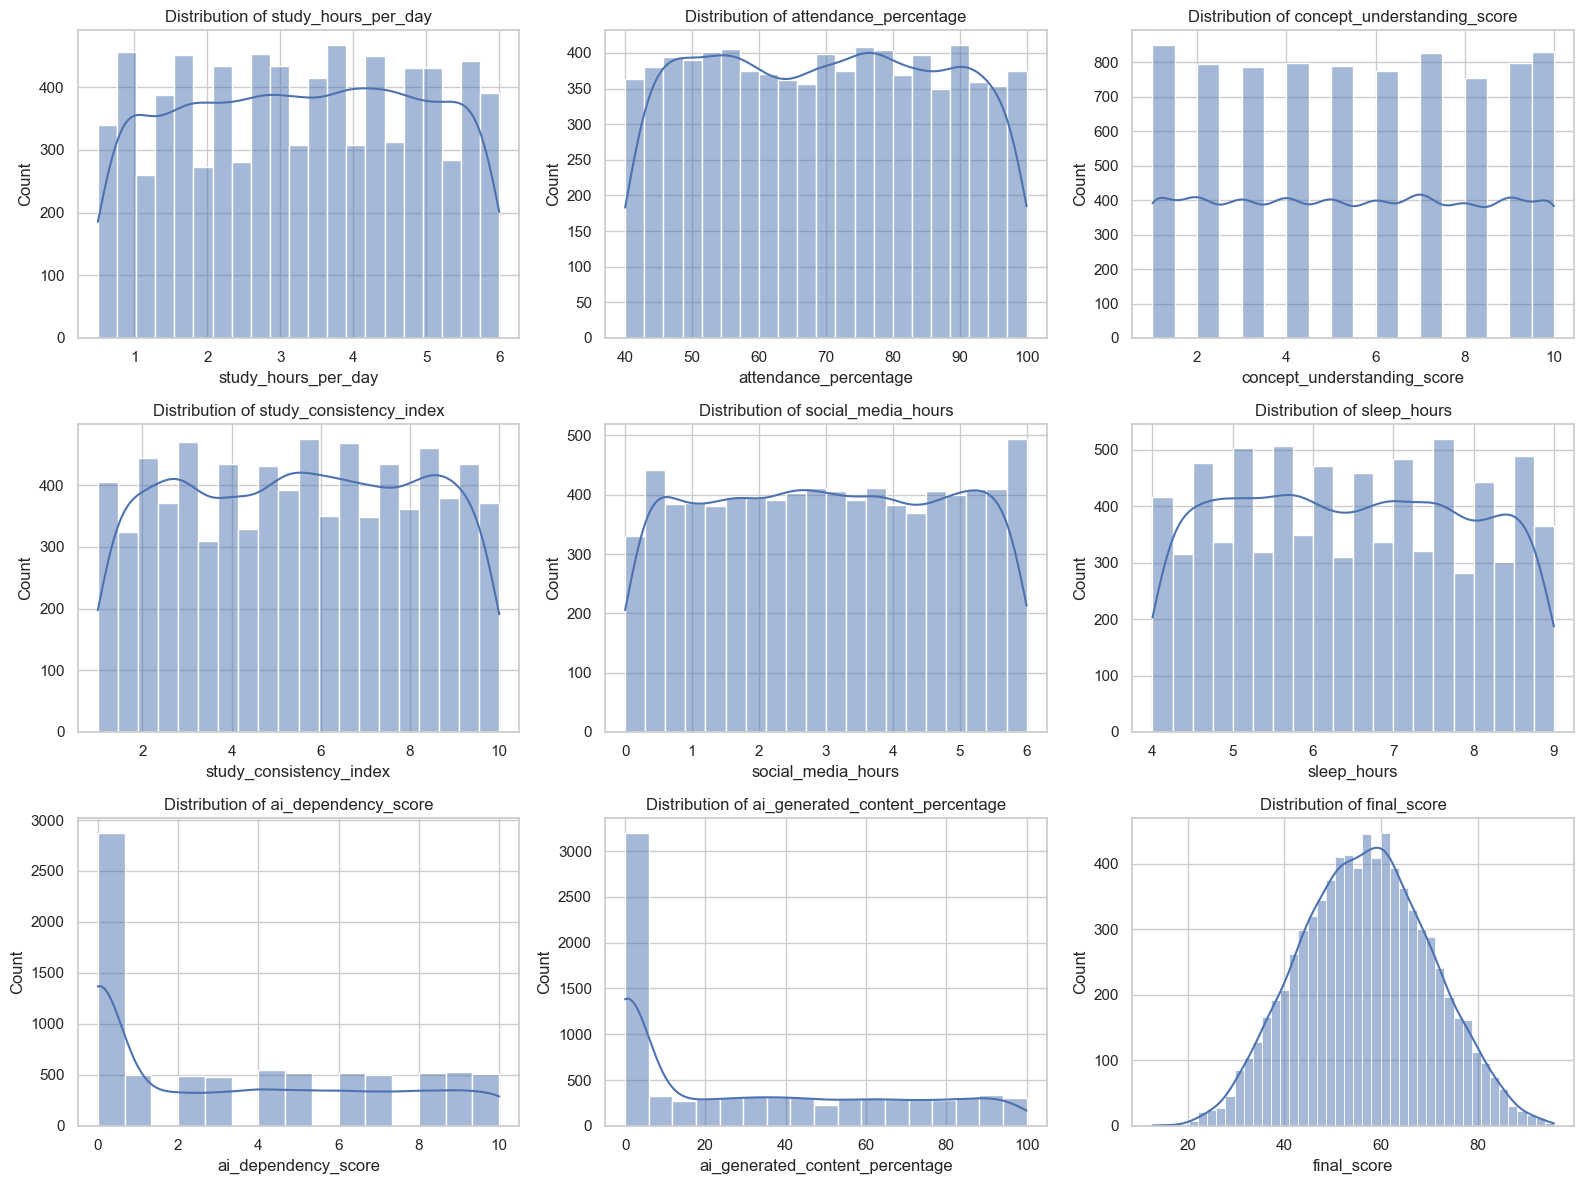

In [85]:

# -----------------------------
# 6.2 Distribution plots | 关键变量分布图
# -----------------------------

dist_cols = [
    "study_hours_per_day", "attendance_percentage", "concept_understanding_score",
    "study_consistency_index", "social_media_hours", "sleep_hours",
    "ai_dependency_score", "ai_generated_content_percentage", "final_score"
]

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for ax, col in zip(axes, dist_cols):
    sns.histplot(data[col], kde=True, ax=ax, color="C0")
    ax.set_title(f"Distribution of {col}")

plt.tight_layout()
plt.show()


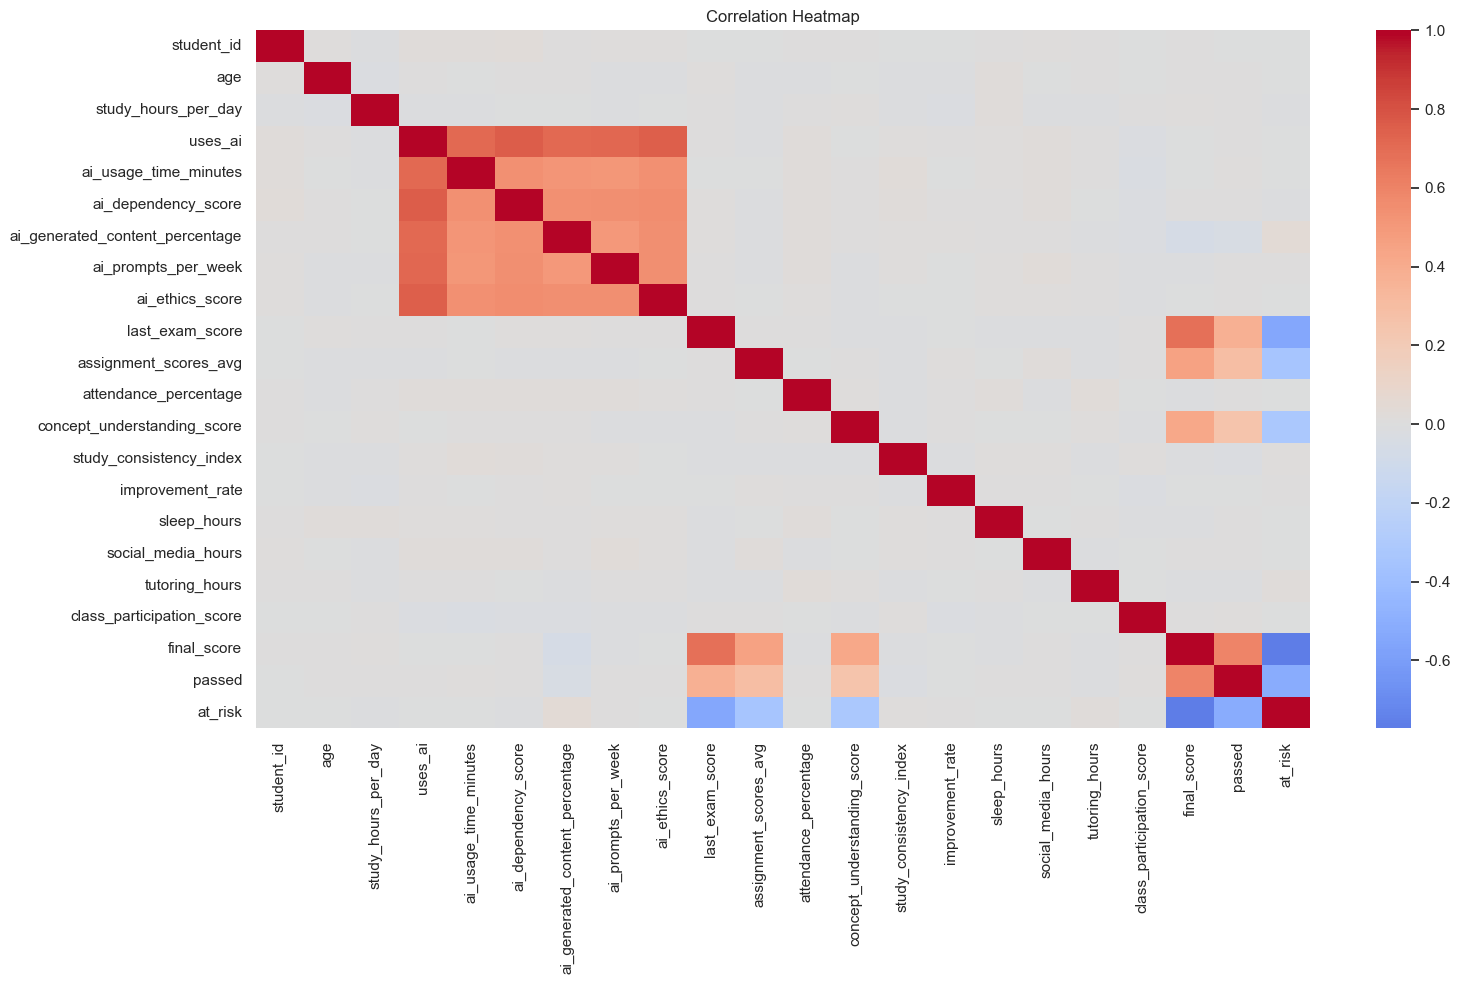

In [86]:

# -----------------------------
# 6.3 Correlation heatmap | 相关性热力图
# -----------------------------

numeric_cols = data.select_dtypes(include=np.number).columns.tolist()
corr_matrix = data[numeric_cols].corr()

plt.figure(figsize=(16, 10))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


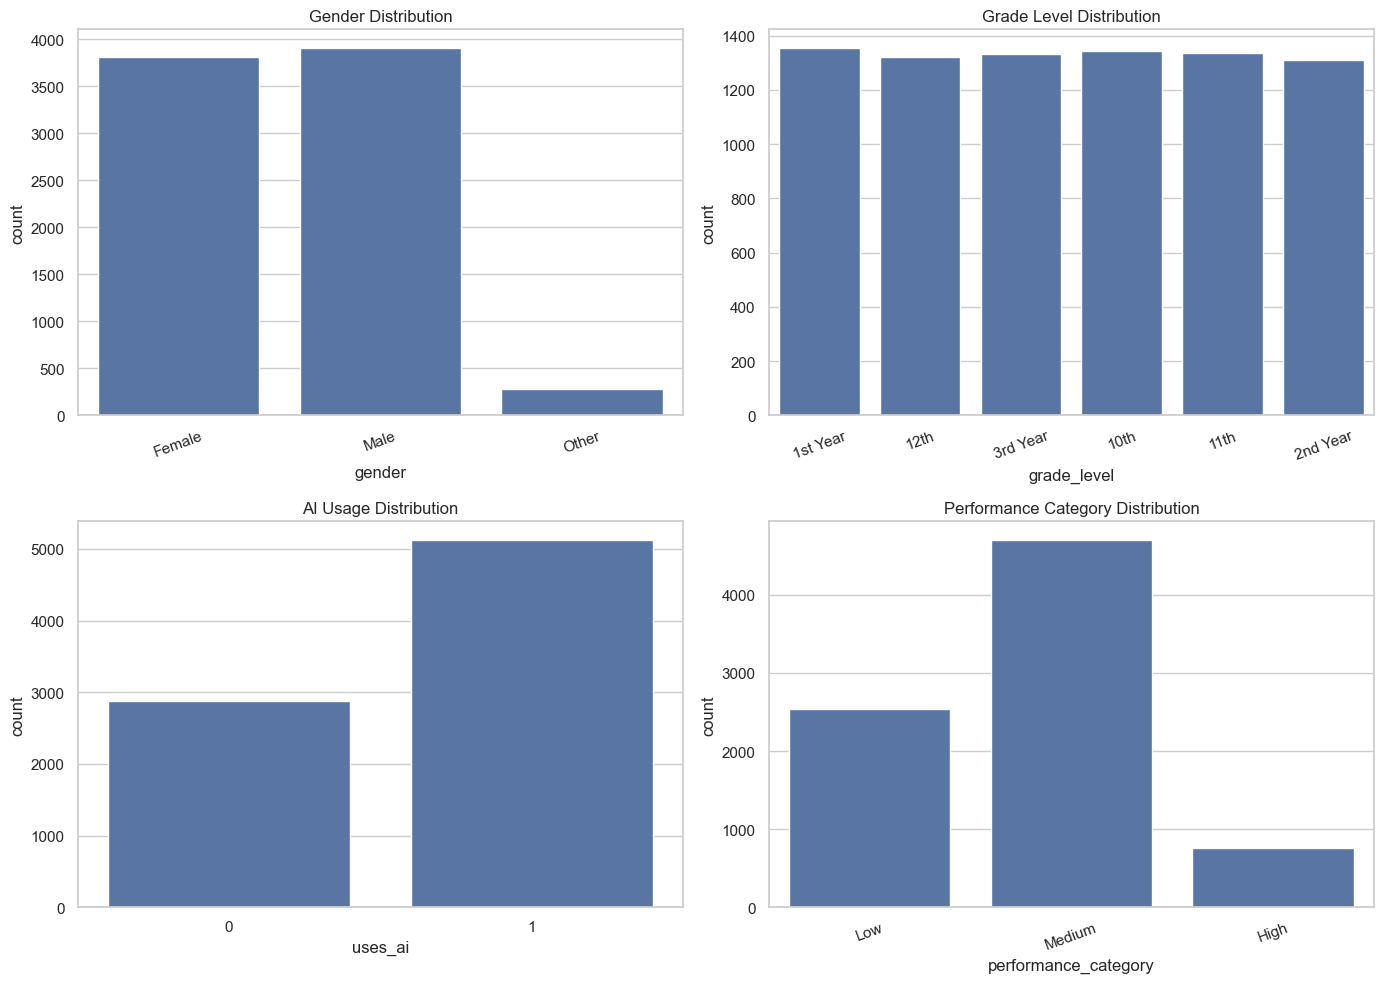

In [87]:

# -----------------------------
# 6.4 Count plots for categorical variables | 类别变量柱状分布图
# -----------------------------

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.countplot(data=data, x="gender", ax=axes[0, 0], color="C0")
axes[0, 0].set_title("Gender Distribution")
axes[0, 0].tick_params(axis='x', rotation=20)

sns.countplot(data=data, x="grade_level", ax=axes[0, 1], color="C0")
axes[0, 1].set_title("Grade Level Distribution")
axes[0, 1].tick_params(axis='x', rotation=20)

sns.countplot(data=data, x="uses_ai", ax=axes[1, 0], color="C0")
axes[1, 0].set_title("AI Usage Distribution")

sns.countplot(data=data, x="performance_category", ax=axes[1, 1], color="C0")
axes[1, 1].set_title("Performance Category Distribution")
axes[1, 1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()


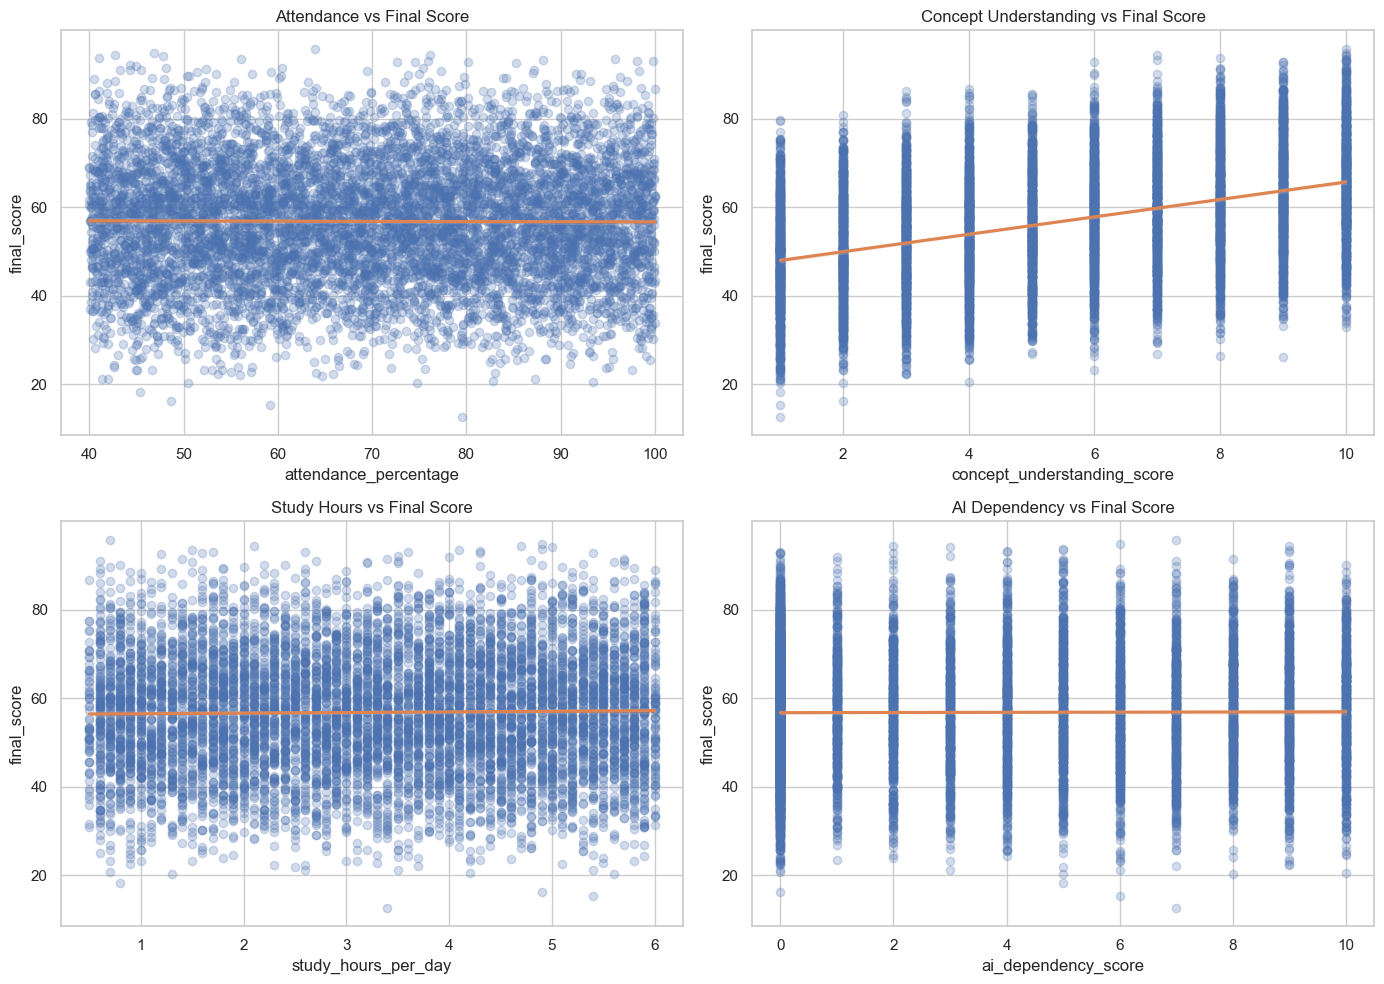

In [88]:

# -----------------------------
# 6.5 Scatter plots with trend lines | 带趋势线的散点图
# -----------------------------

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.regplot(data=data, x="attendance_percentage", y="final_score", scatter_kws={"alpha": 0.25}, line_kws={"color":"C1"}, ax=axes[0, 0])
axes[0, 0].set_title("Attendance vs Final Score")

sns.regplot(data=data, x="concept_understanding_score", y="final_score", scatter_kws={"alpha": 0.25}, line_kws={"color":"C1"}, ax=axes[0, 1])
axes[0, 1].set_title("Concept Understanding vs Final Score")

sns.regplot(data=data, x="study_hours_per_day", y="final_score", scatter_kws={"alpha": 0.25}, line_kws={"color":"C1"}, ax=axes[1, 0])
axes[1, 0].set_title("Study Hours vs Final Score")

sns.regplot(data=data, x="ai_dependency_score", y="final_score", scatter_kws={"alpha": 0.25}, line_kws={"color":"C1"}, ax=axes[1, 1])
axes[1, 1].set_title("AI Dependency vs Final Score")

plt.tight_layout()
plt.show()


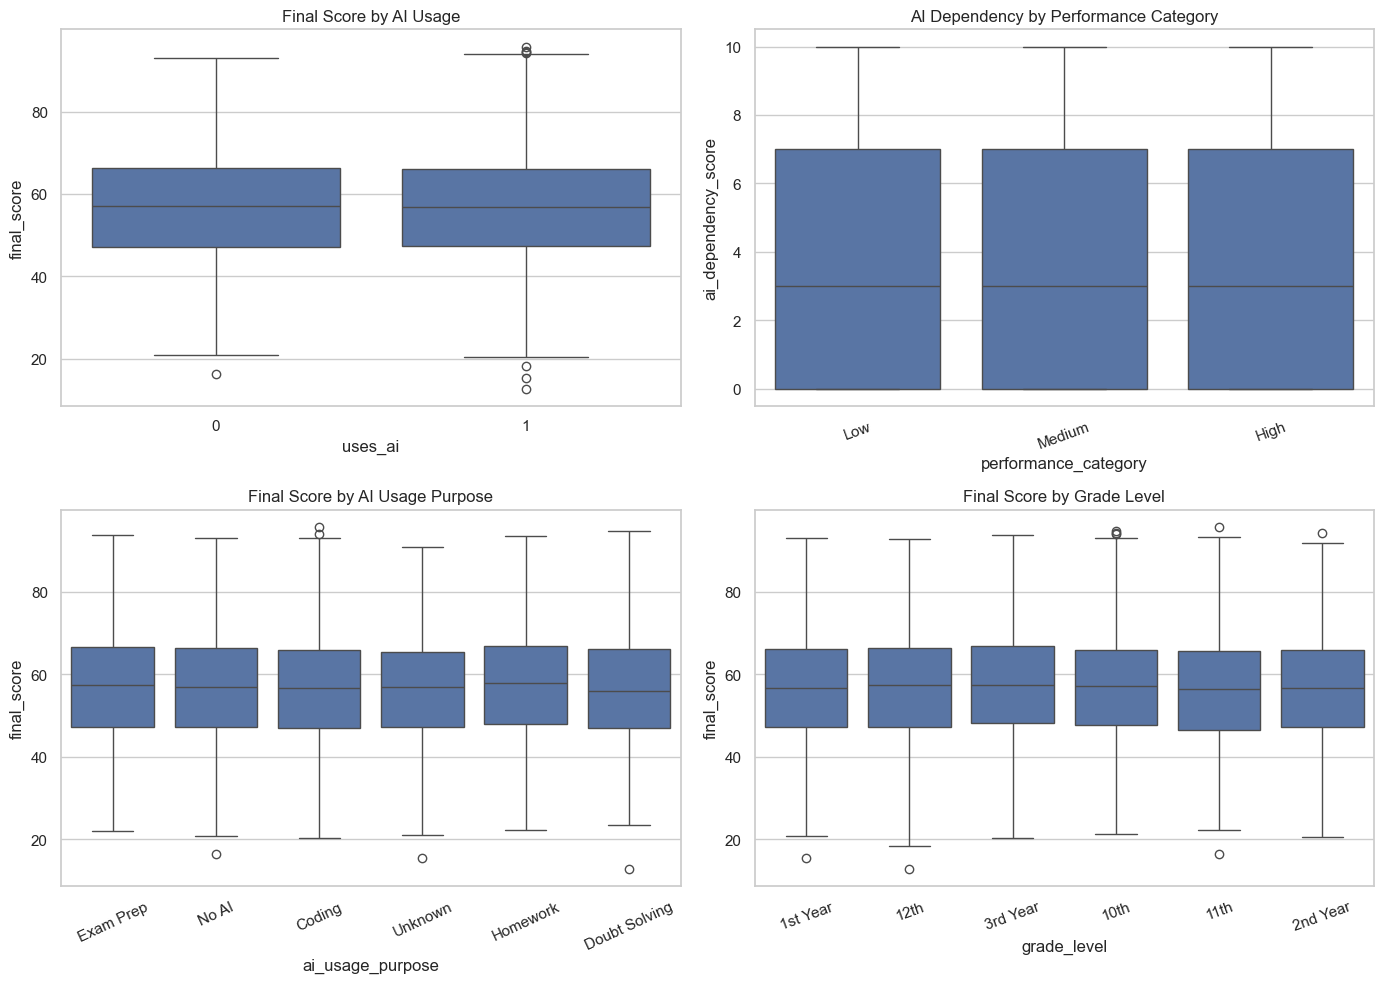

In [89]:

# -----------------------------
# 6.6 Box plots | 箱线图
# -----------------------------

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.boxplot(data=data, x="uses_ai", y="final_score", ax=axes[0, 0], color="C0")
axes[0, 0].set_title("Final Score by AI Usage")

sns.boxplot(data=data, x="performance_category", y="ai_dependency_score", ax=axes[0, 1], color="C0")
axes[0, 1].set_title("AI Dependency by Performance Category")
axes[0, 1].tick_params(axis='x', rotation=20)

top_purposes = data["ai_usage_purpose"].value_counts().head(6).index
temp_box = data[data["ai_usage_purpose"].isin(top_purposes)].copy()
sns.boxplot(data=temp_box, x="ai_usage_purpose", y="final_score", ax=axes[1, 0], color="C0")
axes[1, 0].set_title("Final Score by AI Usage Purpose")
axes[1, 0].tick_params(axis='x', rotation=25)

sns.boxplot(data=data, x="grade_level", y="final_score", ax=axes[1, 1], color="C0")
axes[1, 1].set_title("Final Score by Grade Level")
axes[1, 1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()


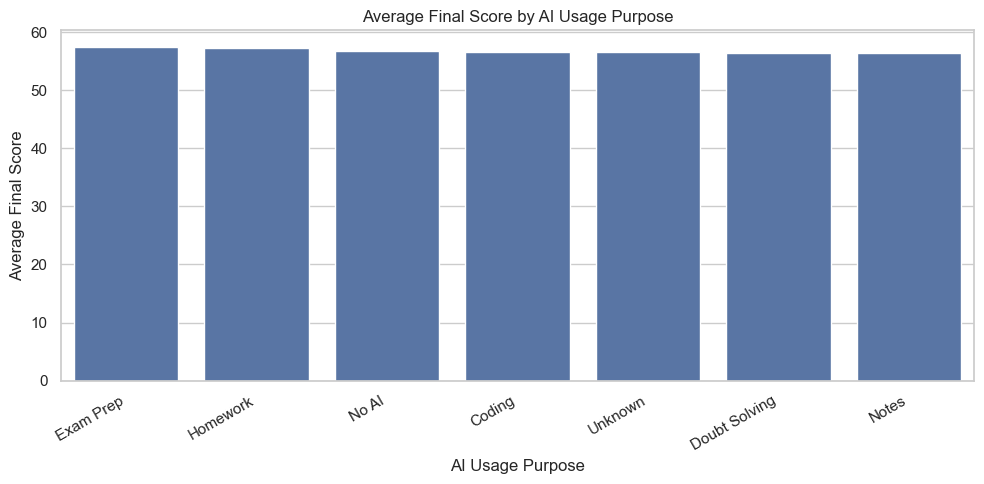

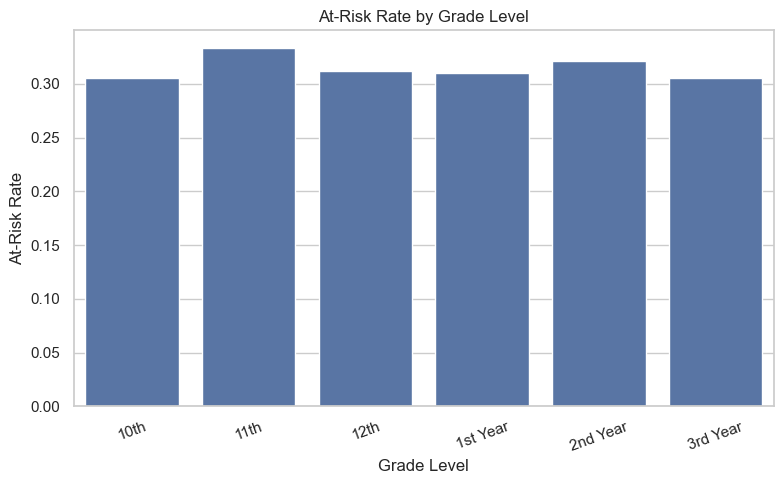

In [109]:

# -----------------------------
# 6.7 Aggregated bar charts | 汇总柱状图
# -----------------------------

# Average final score by AI usage purpose | 不同 AI 使用目的的平均成绩
purpose_score = (
    data.groupby("ai_usage_purpose", as_index=False)["final_score"]
    .mean()
    .sort_values("final_score", ascending=False)
)

plt.figure(figsize=(10, 5))
sns.barplot(data=purpose_score, x="ai_usage_purpose", y="final_score", color="C0")
plt.title("Average Final Score by AI Usage Purpose")
plt.xlabel("AI Usage Purpose")
plt.ylabel("Average Final Score")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# At-risk rate by grade level | 不同年级的高风险比例
risk_by_grade = data.groupby("grade_level", as_index=False)["at_risk"].mean()

plt.figure(figsize=(8, 5))
sns.barplot(data=risk_by_grade, x="grade_level", y="at_risk", color="C0")
plt.title("At-Risk Rate by Grade Level")
plt.xlabel("Grade Level")
plt.ylabel("At-Risk Rate")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()



## 7. Facet Chart analysis (Category A) | 分面图分析（A 类方法）

Facet charts are one of the required Category A methods.  
分面图是课程要求中的 A 类方法之一。

They are useful for communicating segmented patterns to a management audience.  
它们非常适合向管理层展示分组差异和结构性特征。


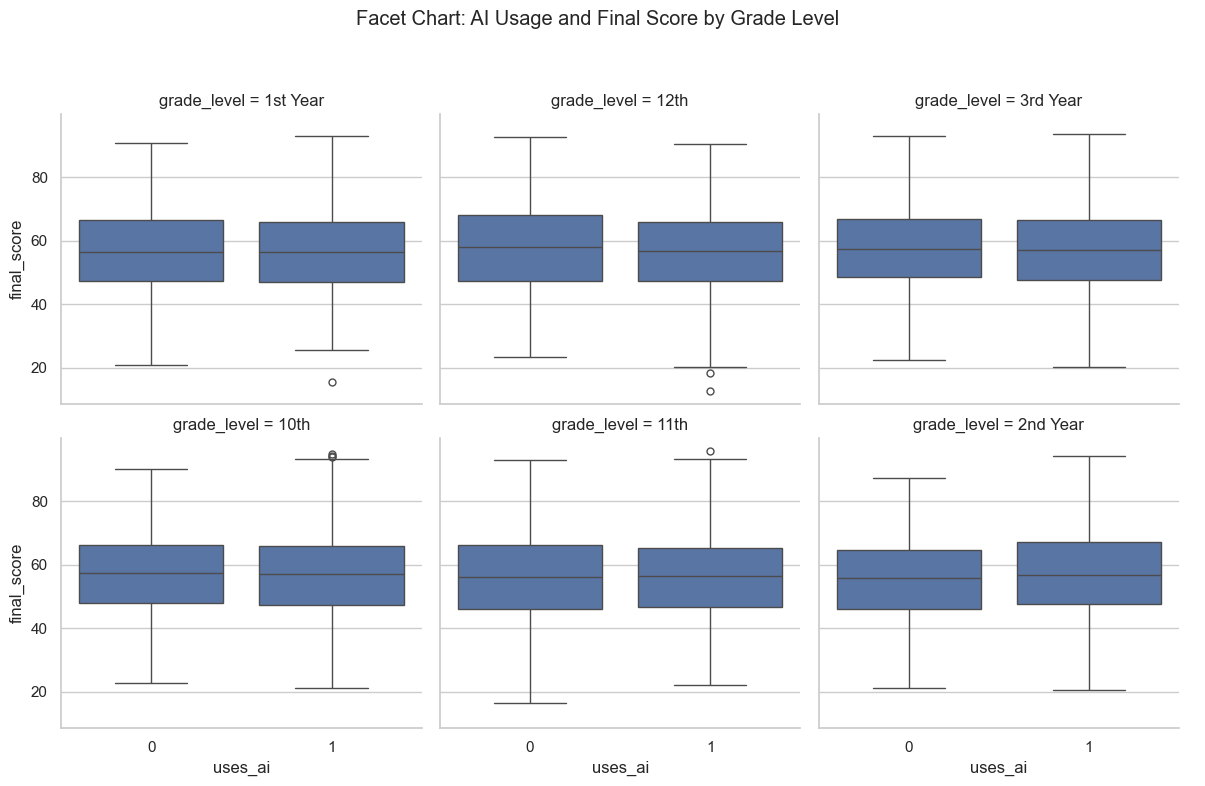

In [91]:

# -----------------------------
# 7.1 Facet chart: AI usage vs final score by grade level
# 7.1 分面图：不同年级中 AI 使用与成绩的关系
# -----------------------------

g = sns.catplot(
    data=data,
    x="uses_ai",
    y="final_score",
    col="grade_level",
    kind="box",
    color="C0",
    col_wrap=3,
    sharey=True,
    height=4
)
g.fig.subplots_adjust(top=0.85)
g.fig.suptitle("Facet Chart: AI Usage and Final Score by Grade Level")
plt.show()


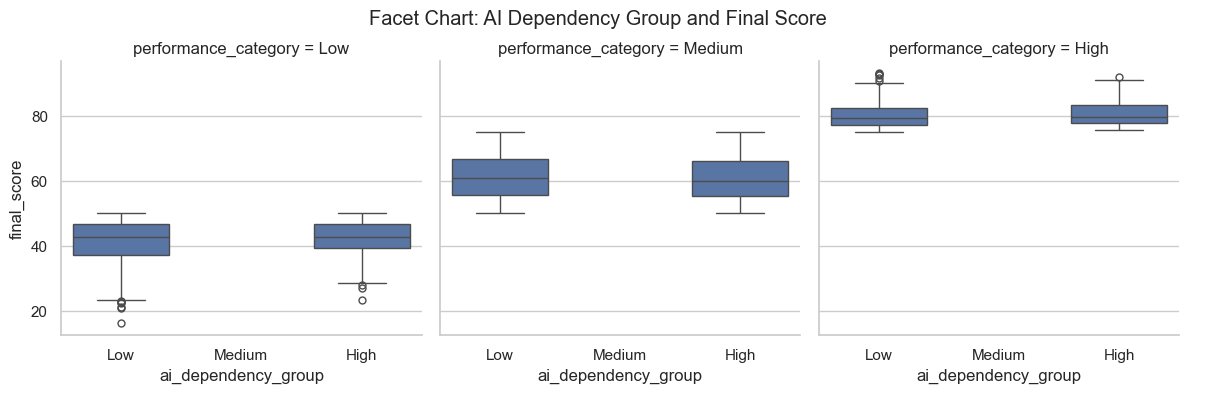

In [92]:

# -----------------------------
# 7.2 Facet chart: AI dependency and final score by performance category
# 7.2 分面图：不同成绩等级中 AI 依赖度与成绩关系
# -----------------------------

# Convert AI dependency score into groups for easier visualization | 将 AI 依赖度分组，便于可视化
data["ai_dependency_group"] = pd.cut(
    data["ai_dependency_score"],
    bins=[-0.01, 0.33, 0.66, 1.0],
    labels=["Low", "Medium", "High"]
)

g = sns.catplot(
    data=data,
    x="ai_dependency_group",
    y="final_score",
    col="performance_category",
    kind="box",
    color="C0",
    col_wrap=3,
    sharey=True,
    height=4
)
g.fig.subplots_adjust(top=0.85)
g.fig.suptitle("Facet Chart: AI Dependency Group and Final Score")
plt.show()



## 8. Modeling preparation | 建模准备

We separate explanatory modeling (`final_score`) from intervention-oriented classification (`at_risk`).  
我们将解释型建模（`final_score`）与干预导向分类（`at_risk`）分开处理。


In [93]:

# -----------------------------
# 8. Prepare feature lists | 准备变量列表
# -----------------------------

target_reg = "final_score"
target_clf = "at_risk"

# Drop helper / leakage columns from features | 删除辅助字段及潜在泄露变量
drop_cols = [
    "student_id", "final_score", "at_risk", "passed", "performance_category", "ai_dependency_group"
]
feature_cols = [col for col in data.columns if col not in drop_cols]

X = data[feature_cols]
y_reg = data[target_reg]
y_clf = data[target_clf]

# Identify numeric and categorical columns | 区分数值变量与类别变量
numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

print("Number of features | 特征数:", len(feature_cols))
print("Numeric features | 数值变量:", numeric_features)
print("Categorical features | 类别变量:", categorical_features)


Number of features | 特征数: 22
Numeric features | 数值变量: ['age', 'study_hours_per_day', 'uses_ai', 'ai_usage_time_minutes', 'ai_dependency_score', 'ai_generated_content_percentage', 'ai_prompts_per_week', 'ai_ethics_score', 'last_exam_score', 'assignment_scores_avg', 'attendance_percentage', 'concept_understanding_score', 'study_consistency_index', 'improvement_rate', 'sleep_hours', 'social_media_hours', 'tutoring_hours', 'class_participation_score']
Categorical features | 类别变量: ['gender', 'grade_level', 'ai_tools_used', 'ai_usage_purpose']



## 8. Modeling preparation and multicollinearity check | 建模准备与共线性检验

Before building the models, we first prepare the feature set and examine multicollinearity among numeric predictors using VIF (Variance Inflation Factor).  
在正式建模之前，我们先准备特征集合，并使用 VIF（方差膨胀因子）对数值型自变量进行多重共线性检验。


In [94]:

# -----------------------------
# 8.1 Prepare feature lists | 准备变量列表
# -----------------------------

target_reg = "final_score"
target_clf = "at_risk"

# Drop helper / leakage columns from features | 删除辅助字段及潜在泄露变量
drop_cols = [
    "student_id", "final_score", "at_risk", "passed", "performance_category", "ai_dependency_group"
]
feature_cols = [col for col in data.columns if col not in drop_cols]

X = data[feature_cols].copy()
y_reg = data[target_reg].copy()
y_clf = data[target_clf].copy()

# Identify numeric and categorical columns | 区分数值变量与类别变量
numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

# Treat 'uses_ai' as categorical since it's binary | 将 'uses_ai' 视为类别变量，因为它是二元的
if 'uses_ai' in numeric_features:
    numeric_features.remove('uses_ai')
    categorical_features.append('uses_ai')

print("Number of features | 特征数:", len(feature_cols))
print("Numeric features | 数值变量:", numeric_features)
print("Categorical features | 类别变量:", categorical_features)


Number of features | 特征数: 22
Numeric features | 数值变量: ['age', 'study_hours_per_day', 'ai_usage_time_minutes', 'ai_dependency_score', 'ai_generated_content_percentage', 'ai_prompts_per_week', 'ai_ethics_score', 'last_exam_score', 'assignment_scores_avg', 'attendance_percentage', 'concept_understanding_score', 'study_consistency_index', 'improvement_rate', 'sleep_hours', 'social_media_hours', 'tutoring_hours', 'class_participation_score']
Categorical features | 类别变量: ['gender', 'grade_level', 'ai_tools_used', 'ai_usage_purpose', 'uses_ai']


In [95]:

# -----------------------------
# 8.2 VIF multicollinearity test | VIF 多重共线性检验
# -----------------------------

# VIF is computed on numeric predictors only | VIF 仅对数值型自变量进行检验
X_vif = X[numeric_features].copy()

# Fill missing values to avoid VIF computation errors | 填补缺失值，避免 VIF 计算报错
X_vif = X_vif.fillna(X_vif.median(numeric_only=True))

# Add constant term | 添加常数项
X_vif_const = sm.add_constant(X_vif)

vif_df = pd.DataFrame({
    "Feature": X_vif_const.columns,
    "VIF": [variance_inflation_factor(X_vif_const.values, i) for i in range(X_vif_const.shape[1])]
})

# Remove the intercept row when interpreting VIF | 解读时不考虑常数项
vif_df_clean = vif_df[vif_df["Feature"] != "const"].copy().sort_values("VIF", ascending=False)

display(vif_df_clean)

# Common rule of thumb: VIF > 5 indicates moderate/high multicollinearity
# 常见经验法则：VIF > 5 表示存在中度或较高共线性
vif_threshold = 5
high_vif_features = vif_df_clean.loc[vif_df_clean["VIF"] > vif_threshold, "Feature"].tolist()

print(f"VIF threshold | VIF 阈值: {vif_threshold}")
print("High-VIF features | 高 VIF 变量:", high_vif_features if high_vif_features else "None | 无")

# Keep numeric features that pass the VIF check | 保留通过 VIF 检验的数值变量
numeric_features_model = [f for f in numeric_features if f not in high_vif_features]

print("Numeric features retained for modeling | 建模保留的数值变量:")
print(numeric_features_model)


,Feature,VIF
7,ai_ethics_score,1.878766
4,ai_dependency_score,1.861367
5,ai_generated_content_percentage,1.740267
6,ai_prompts_per_week,1.738175
3,ai_usage_time_minutes,1.736023
10,attendance_percentage,1.002560
12,study_consistency_index,1.002350
2,study_hours_per_day,1.002334
17,class_participation_score,1.002084
14,sleep_hours,1.002065


VIF threshold | VIF 阈值: 5
High-VIF features | 高 VIF 变量: None | 无
Numeric features retained for modeling | 建模保留的数值变量:
['age', 'study_hours_per_day', 'ai_usage_time_minutes', 'ai_dependency_score', 'ai_generated_content_percentage', 'ai_prompts_per_week', 'ai_ethics_score', 'last_exam_score', 'assignment_scores_avg', 'attendance_percentage', 'concept_understanding_score', 'study_consistency_index', 'improvement_rate', 'sleep_hours', 'social_media_hours', 'tutoring_hours', 'class_participation_score']


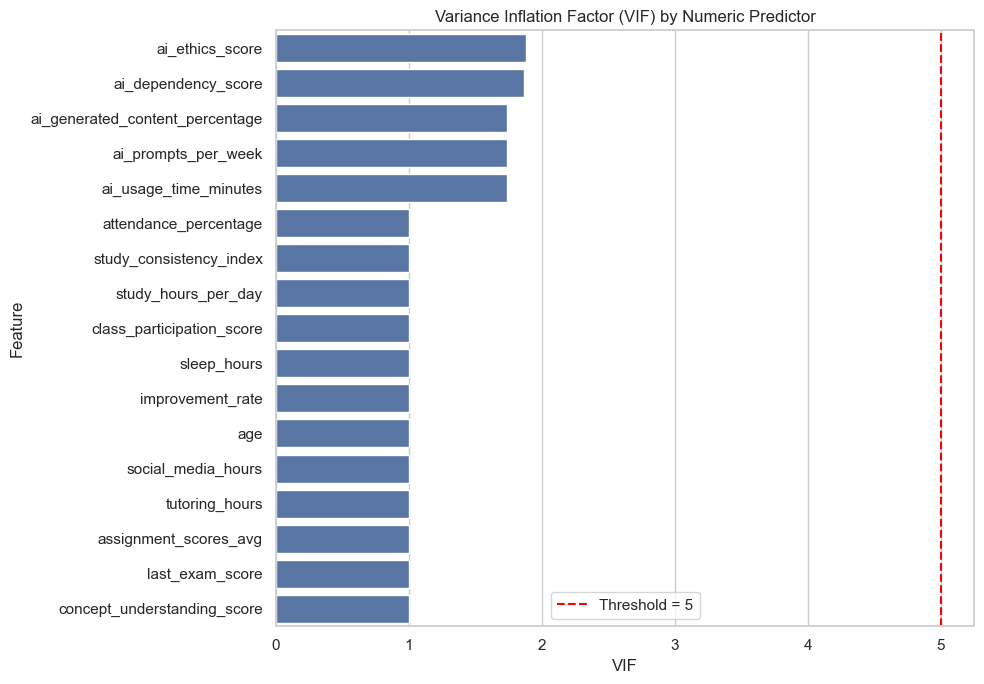

In [96]:

# -----------------------------
# 8.3 VIF bar chart | VIF 柱状图
# -----------------------------

plt.figure(figsize=(10, 7))
sns.barplot(data=vif_df_clean.sort_values("VIF", ascending=False), x="VIF", y="Feature", color="C0")
plt.axvline(vif_threshold, color="red", linestyle="--", label=f"Threshold = {vif_threshold}")
plt.title("Variance Inflation Factor (VIF) by Numeric Predictor")
plt.xlabel("VIF")
plt.ylabel("Feature")
plt.legend()
plt.tight_layout()
plt.show()



## 9. Linear Regression (Category A) | 线性回归（A 类方法）

This model explains which variables are associated with higher or lower final scores.  
该模型用于解释哪些变量与更高或更低的期末成绩相关。


In [97]:

# -----------------------------
# 9.1 Train-test split and pipeline for regression | 回归任务训练测试集划分与流水线
# -----------------------------

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

# Build regression preprocessor with VIF-screened numeric variables
# 使用通过 VIF 检验后的数值变量构建回归预处理器
preprocessor_reg = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_features_model),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_features)
    ],
    remainder="drop"
)

linreg_model = Pipeline(steps=[
    ("preprocessor", preprocessor_reg),
    ("model", LinearRegression())
])

linreg_model.fit(X_train_reg, y_train_reg)
y_pred_reg = linreg_model.predict(X_test_reg)


In [98]:

# -----------------------------
# 9.2 Regression metrics | 回归模型评估指标
# -----------------------------

rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
mae = mean_absolute_error(y_test_reg, y_pred_reg)
r2 = r2_score(y_test_reg, y_pred_reg)

reg_metrics_df = pd.DataFrame({
    "Metric": ["RMSE", "MAE", "R-squared"],
    "Value": [rmse, mae, r2]
})

display(reg_metrics_df)

print(f"Linear Regression RMSE | 线性回归 RMSE: {rmse:.4f}")
print(f"Linear Regression MAE  | 线性回归 MAE : {mae:.4f}")
print(f"Linear Regression R^2  | 线性回归 R^2 : {r2:.4f}")


,Metric,Value
0,RMSE,4.968250
1,MAE,3.959239
2,R-squared,0.867275


Linear Regression RMSE | 线性回归 RMSE: 4.9682
Linear Regression MAE  | 线性回归 MAE : 3.9592
Linear Regression R^2  | 线性回归 R^2 : 0.8673


In [99]:

# -----------------------------
# 9.3 Cross-validation for regression | 回归交叉验证
# -----------------------------

cv_reg = KFold(n_splits=5, shuffle=True, random_state=42)

cv_r2_scores = cross_val_score(linreg_model, X, y_reg, cv=cv_reg, scoring="r2")
cv_rmse_scores = -cross_val_score(
    linreg_model, X, y_reg, cv=cv_reg, scoring="neg_root_mean_squared_error"
)

cv_reg_df = pd.DataFrame({
    "Fold": np.arange(1, 6),
    "R2": cv_r2_scores,
    "RMSE": cv_rmse_scores
})

display(cv_reg_df)

print(f"Mean CV R^2   | 平均交叉验证 R^2  : {cv_r2_scores.mean():.4f}")
print(f"Mean CV RMSE  | 平均交叉验证 RMSE : {cv_rmse_scores.mean():.4f}")


,Fold,R2,RMSE
0,1,0.867275,4.968250
1,2,0.847709,5.131462
2,3,0.856148,5.149731
3,4,0.862159,5.039117
4,5,0.849909,5.155128


Mean CV R^2   | 平均交叉验证 R^2  : 0.8566
Mean CV RMSE  | 平均交叉验证 RMSE : 5.0887


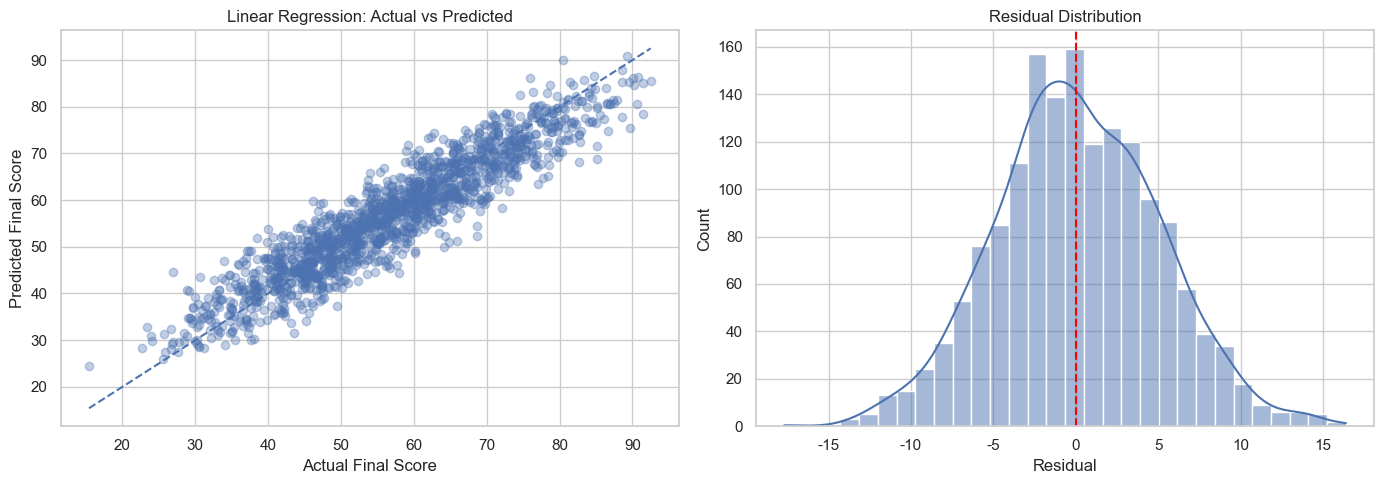

In [110]:

# -----------------------------
# 9.4 Actual vs predicted and residual diagnostics | 预测对比与残差诊断
# -----------------------------

residuals = y_test_reg - y_pred_reg

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted | 真实值与预测值
axes[0].scatter(y_test_reg, y_pred_reg, alpha=0.35)
min_val = min(y_test_reg.min(), y_pred_reg.min())
max_val = max(y_test_reg.max(), y_pred_reg.max())
axes[0].plot([min_val, max_val], [min_val, max_val], linestyle="--")
axes[0].set_title("Linear Regression: Actual vs Predicted")
axes[0].set_xlabel("Actual Final Score")
axes[0].set_ylabel("Predicted Final Score")

# Residual distribution | 残差分布
sns.histplot(residuals, bins=30, kde=True, ax=axes[1], color="C0")
axes[1].axvline(0, color="red", linestyle="--")
axes[1].set_title("Residual Distribution")
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()


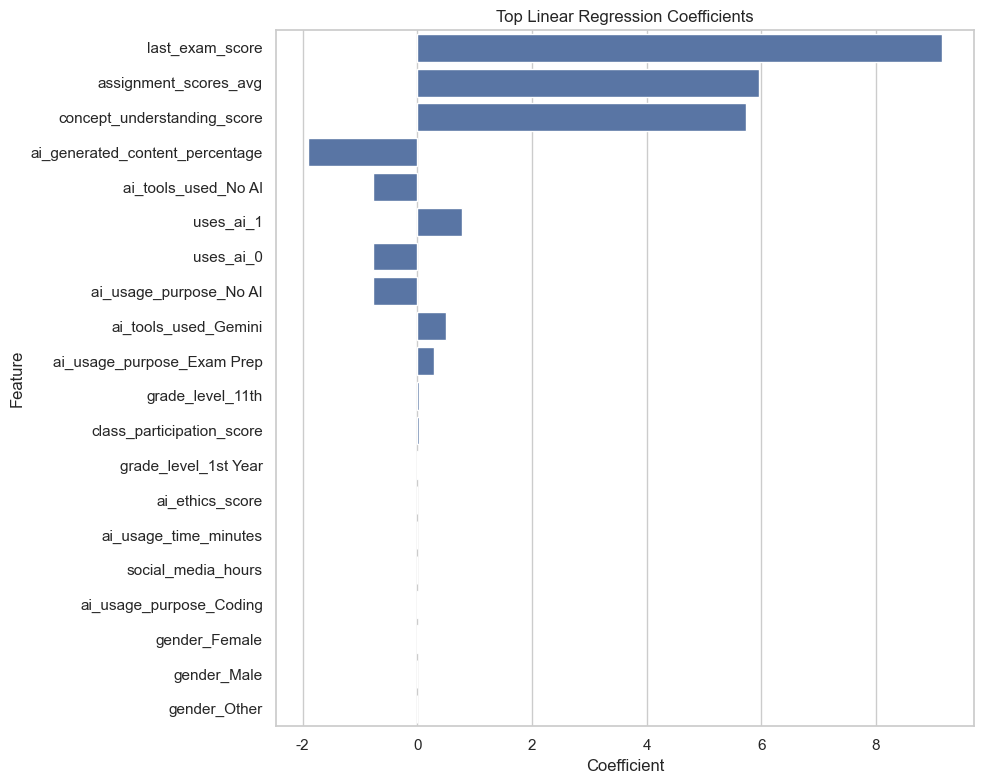

,feature,coefficient
7,last_exam_score,9.155131
8,assignment_scores_avg,5.966289
10,concept_understanding_score,5.726316
4,ai_generated_content_percentage,-1.909966
31,ai_tools_used_No AI,-0.773511
41,uses_ai_1,0.773511
40,uses_ai_0,-0.773511
37,ai_usage_purpose_No AI,-0.773511
30,ai_tools_used_Gemini,0.496282
35,ai_usage_purpose_Exam Prep,0.297715


In [111]:

# -----------------------------
# 9.5 Top coefficients plot | 关键系数可视化
# -----------------------------

# Retrieve transformed feature names | 获取转换后的特征名称
ohe_reg = linreg_model.named_steps["preprocessor"].named_transformers_["cat"].named_steps["onehot"]
encoded_cat_names_reg = ohe_reg.get_feature_names_out(categorical_features).tolist()
all_feature_names_reg = numeric_features_model + encoded_cat_names_reg

coef_df = pd.DataFrame({
    "feature": all_feature_names_reg,
    "coefficient": linreg_model.named_steps["model"].coef_
}).sort_values("coefficient", key=np.abs, ascending=False)

top_coef = pd.concat([coef_df.head(10), coef_df.tail(10)])

plt.figure(figsize=(10, 8))
sns.barplot(data=top_coef, x="coefficient", y="feature", color="C0")
plt.title("Top Linear Regression Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

display(coef_df.head(15))



## 10. Logistic Regression (Category A) | 逻辑回归（A 类方法）

This model predicts whether a student belongs to the `at_risk` group.  
该模型用于预测学生是否属于 `at_risk` 高风险群体。


In [102]:

# -----------------------------
# 10.1 Train-test split and pipeline for classification | 分类任务训练测试集划分与流水线
# -----------------------------

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

preprocessor_clf = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_features_model),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_features)
    ],
    remainder="drop"
)

# Use class_weight='balanced' to handle possible class imbalance
# 使用 class_weight='balanced' 处理潜在类别不平衡
logreg_model = Pipeline(steps=[
    ("preprocessor", preprocessor_clf),
    ("model", LogisticRegression(max_iter=3000, class_weight="balanced"))
])

logreg_model.fit(X_train_clf, y_train_clf)
y_pred_clf = logreg_model.predict(X_test_clf)
y_prob_clf = logreg_model.predict_proba(X_test_clf)[:, 1]

print("Classification report | 分类报告:")
print(classification_report(y_test_clf, y_pred_clf))


Classification report | 分类报告:
              precision    recall  f1-score   support

           0       0.96      0.88      0.92      1097
           1       0.78      0.91      0.84       503

    accuracy                           0.89      1600
   macro avg       0.87      0.90      0.88      1600
weighted avg       0.90      0.89      0.89      1600



In [103]:

# -----------------------------
# 10.2 Classification metrics and cross-validation | 分类指标与交叉验证
# -----------------------------

acc = accuracy_score(y_test_clf, y_pred_clf)
prec = precision_score(y_test_clf, y_pred_clf)
rec = recall_score(y_test_clf, y_pred_clf)
f1 = f1_score(y_test_clf, y_pred_clf)
auc_score = roc_auc_score(y_test_clf, y_prob_clf)
ap_score = average_precision_score(y_test_clf, y_prob_clf)

test_metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC", "Average Precision"],
    "Value": [acc, prec, rec, f1, auc_score, ap_score]
})

display(test_metrics_df)

cv_clf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = cross_validate(
    logreg_model,
    X,
    y_clf,
    cv=cv_clf,
    scoring=["accuracy", "precision", "recall", "f1", "roc_auc"],
    return_train_score=False
)

cv_metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"],
    "Mean CV Score": [
        cv_results["test_accuracy"].mean(),
        cv_results["test_precision"].mean(),
        cv_results["test_recall"].mean(),
        cv_results["test_f1"].mean(),
        cv_results["test_roc_auc"].mean()
    ]
})

display(cv_metrics_df)


,Metric,Value
0,Accuracy,0.891250
1,Precision,0.779287
2,Recall,0.912525
3,F1-score,0.840659
4,ROC-AUC,0.960471
5,Average Precision,0.920941


,Metric,Mean CV Score
0,Accuracy,0.887375
1,Precision,0.776352
2,Recall,0.903466
3,F1-score,0.834866
4,ROC-AUC,0.960665


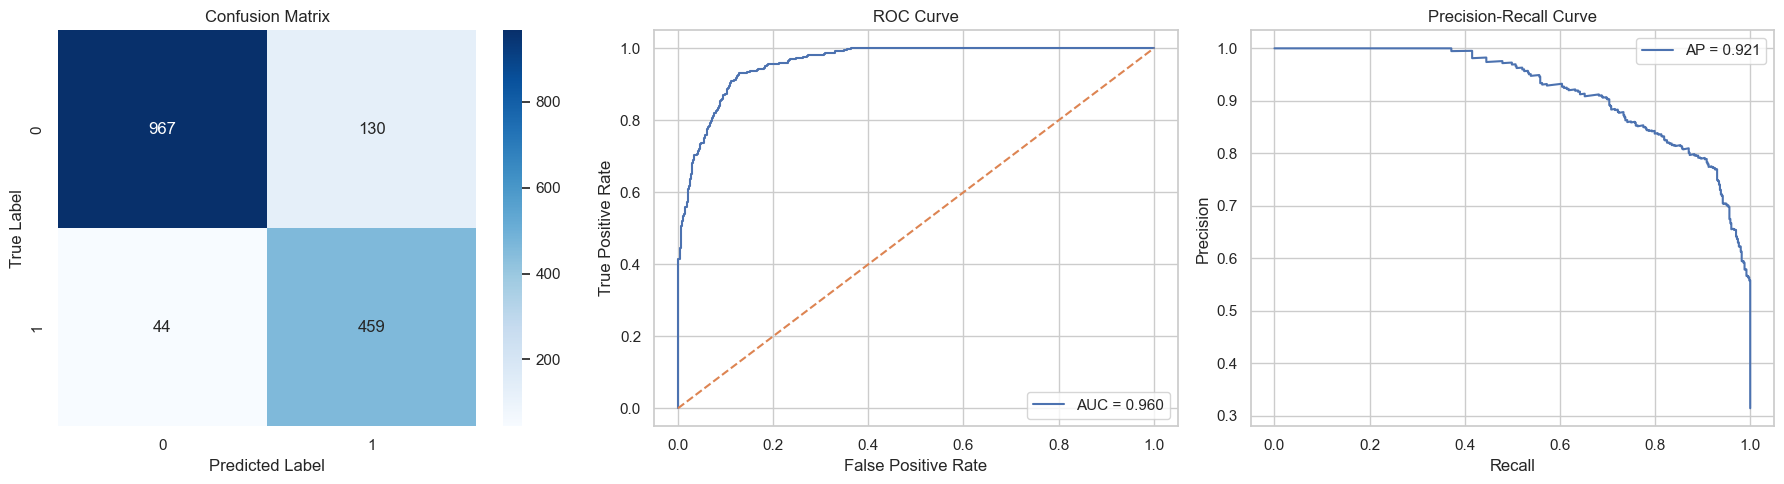

In [112]:

# -----------------------------
# 10.3 Confusion matrix, ROC curve, and PR curve | 混淆矩阵、ROC 曲线与 PR 曲线
# -----------------------------

cm = confusion_matrix(y_test_clf, y_pred_clf)
fpr, tpr, _ = roc_curve(y_test_clf, y_prob_clf)
precision_curve, recall_curve, _ = precision_recall_curve(y_test_clf, y_prob_clf)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion Matrix | 混淆矩阵
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title("Confusion Matrix")
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")

# ROC Curve | ROC 曲线
axes[1].plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
axes[1].plot([0, 1], [0, 1], linestyle="--")
axes[1].set_title("ROC Curve")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend()

# Precision-Recall Curve | 精确率-召回率曲线
axes[2].plot(recall_curve, precision_curve, label=f"AP = {ap_score:.3f}")
axes[2].set_title("Precision-Recall Curve")
axes[2].set_xlabel("Recall")
axes[2].set_ylabel("Precision")
axes[2].legend()

plt.tight_layout()
plt.show()


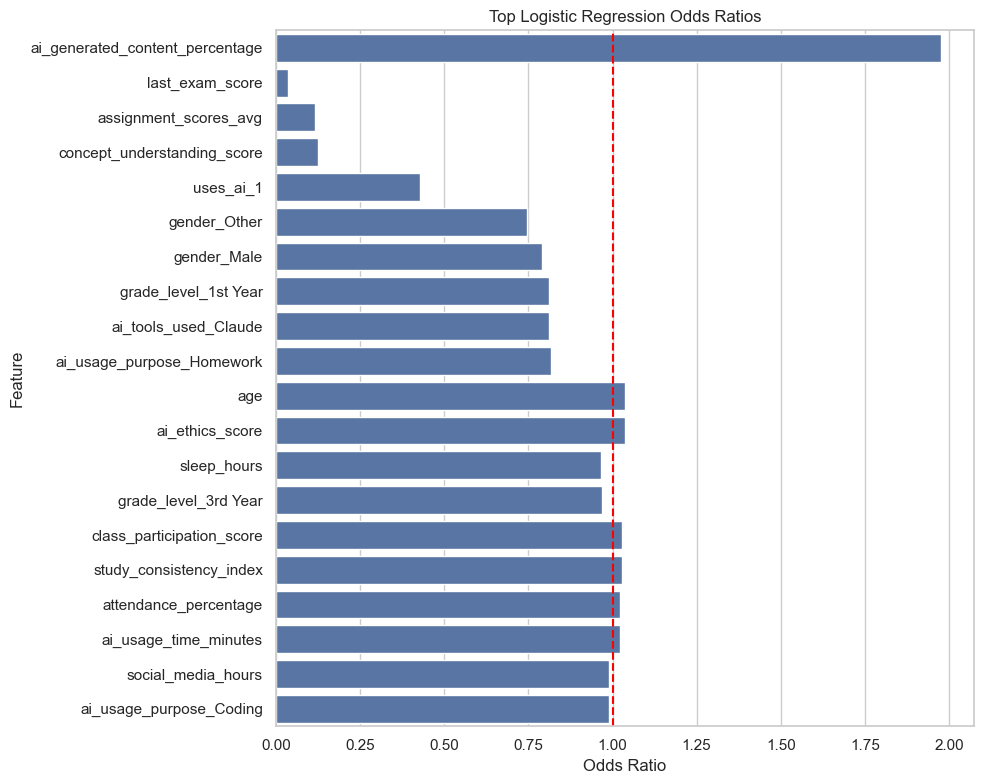

,feature,coefficient,odds_ratio
4,ai_generated_content_percentage,0.680965,1.975784
7,last_exam_score,-3.344609,0.035274
8,assignment_scores_avg,-2.155712,0.115821
10,concept_understanding_score,-2.075594,0.125482
41,uses_ai_1,-0.848548,0.428036
19,gender_Other,-0.291556,0.747100
18,gender_Male,-0.234321,0.791108
23,grade_level_1st Year,-0.210767,0.809963
28,ai_tools_used_Claude,-0.207977,0.812226
36,ai_usage_purpose_Homework,-0.201451,0.817544


In [113]:

# -----------------------------
# 10.4 Odds ratio style coefficient plot | 基于优势比的关键系数图
# -----------------------------

ohe_clf = logreg_model.named_steps["preprocessor"].named_transformers_["cat"].named_steps["onehot"]
encoded_cat_names_clf = ohe_clf.get_feature_names_out(categorical_features).tolist()
all_feature_names_clf = numeric_features_model + encoded_cat_names_clf

log_coef_df = pd.DataFrame({
    "feature": all_feature_names_clf,
    "coefficient": logreg_model.named_steps["model"].coef_[0]
})

log_coef_df["odds_ratio"] = np.exp(log_coef_df["coefficient"])
log_coef_df["distance_from_1"] = np.abs(log_coef_df["odds_ratio"] - 1)
log_coef_df = log_coef_df.sort_values("distance_from_1", ascending=False)

top_or = pd.concat([log_coef_df.head(10), log_coef_df.tail(10)])

plt.figure(figsize=(10, 8))
sns.barplot(data=top_or, x="odds_ratio", y="feature", color="C0")
plt.axvline(1, color="red", linestyle="--")
plt.title("Top Logistic Regression Odds Ratios")
plt.xlabel("Odds Ratio")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

display(log_coef_df[["feature", "coefficient", "odds_ratio"]])



## 11. Lasso Regression (Category B) | Lasso 回归（B 类方法）

Lasso is used as the required complementary Category B method.  
Lasso 用作课程要求中的补充 B 类方法。

Its main purpose is feature selection: less important variables are shrunk toward zero.  
其核心作用是变量筛选：不重要变量的系数会被压缩到接近 0。


In [106]:

# -----------------------------
# 11.1 Prepare data for Lasso and fit model | 为 Lasso 准备数据并拟合模型
# -----------------------------

# Use VIF-filtered numeric features and all categorical features
# 使用通过 VIF 检验的数值变量和全部类别变量
X_lasso = pd.concat(
    [
        X[numeric_features_model].copy(),
        pd.get_dummies(X[categorical_features], drop_first=True)
    ],
    axis=1
)

# Missing value handling | 缺失值处理
X_lasso = X_lasso.fillna(X_lasso.median(numeric_only=True))

# Scale features because Lasso is scale-sensitive | 由于 Lasso 对量纲敏感，需要标准化
scaler = StandardScaler()
X_lasso_scaled = scaler.fit_transform(X_lasso)

lasso = LassoCV(cv=5, random_state=42)
lasso.fit(X_lasso_scaled, y_reg)

# Compute and display MSE based on in-sample predictions and CV path
from sklearn.metrics import mean_squared_error

y_pred_lasso = lasso.predict(X_lasso_scaled)
lasso_mse = mean_squared_error(y_reg, y_pred_lasso)
lasso_cv_mse = lasso.mse_path_.mean(axis=1).min()

lasso_coef = pd.Series(lasso.coef_, index=X_lasso.columns)
selected_features = lasso_coef[lasso_coef != 0].sort_values(key=np.abs, ascending=False)

print(f"Optimal alpha | 最优 alpha: {lasso.alpha_:.6f}")
print(f"Number of selected features | 选中的特征数量: {selected_features.shape[0]}")
print(f"Lasso training MSE (in-sample) | 训练 MSE（样本内）: {lasso_mse:.4f}")
print(f"Lasso best CV mean MSE | 最优交叉验证均方误差: {lasso_cv_mse:.4f}")

# Compute CV scores for Lasso | 计算 Lasso 的交叉验证分数
from sklearn.model_selection import cross_val_score, cross_validate

cv_lasso = cross_validate(
    lasso, X_lasso_scaled, y_reg, cv=5, 
    scoring=['r2', 'neg_mean_squared_error'], return_train_score=False
)

lasso_cv_r2 = cv_lasso['test_r2'].mean()
lasso_cv_rmse = np.sqrt(-cv_lasso['test_neg_mean_squared_error'].mean())

print(f"Lasso CV R² | Lasso 交叉验证 R²: {lasso_cv_r2:.4f}")
print(f"Lasso CV RMSE | Lasso 交叉验证 RMSE: {lasso_cv_rmse:.4f}")

display(selected_features.head(20).to_frame("coefficient"))


Optimal alpha | 最优 alpha: 0.028010
Number of selected features | 选中的特征数量: 22
Lasso training MSE (in-sample) | 训练 MSE（样本内）: 25.6180
Lasso best CV mean MSE | 最优交叉验证均方误差: 25.7569
Lasso CV R² | Lasso 交叉验证 R²: 0.8575
Lasso CV RMSE | Lasso 交叉验证 RMSE: 5.0752


,coefficient
last_exam_score,9.169703
assignment_scores_avg,5.982039
concept_understanding_score,5.709931
ai_generated_content_percentage,-1.781110
uses_ai,1.259468
attendance_percentage,-0.126274
ai_prompts_per_week,-0.101150
study_hours_per_day,0.088046
tutoring_hours,-0.082605
ai_tools_used_Gemini,0.082139


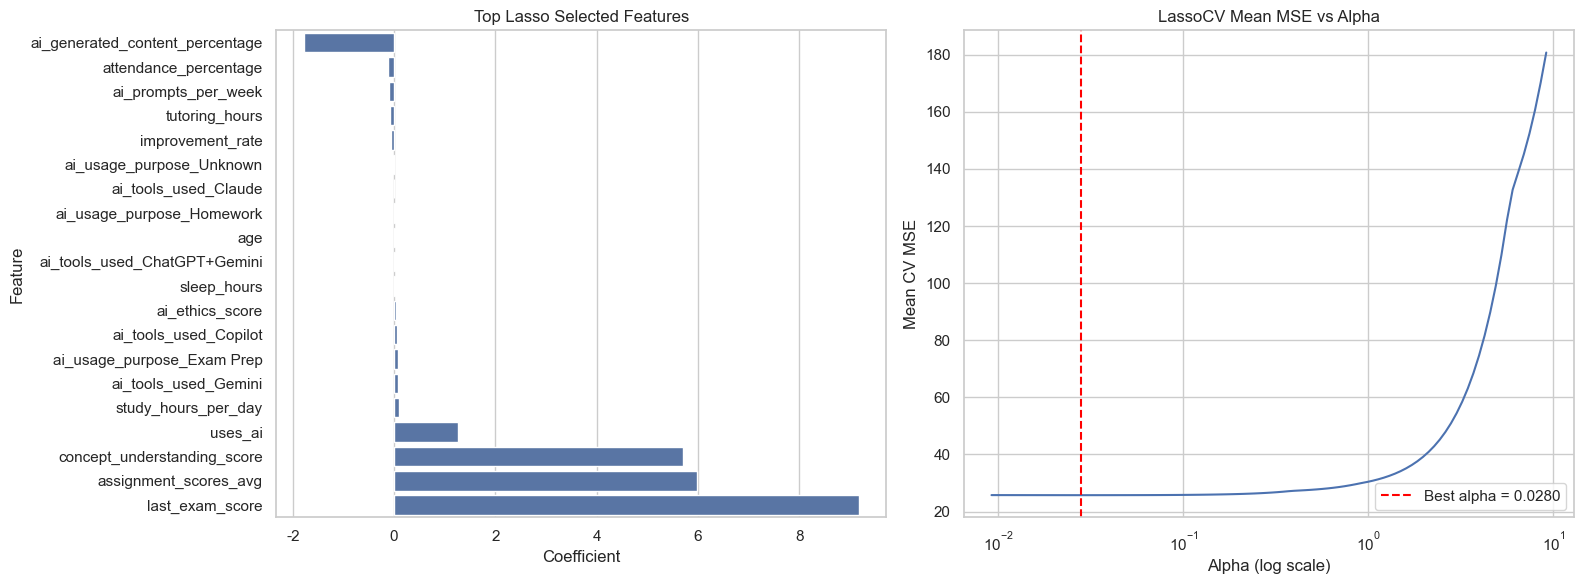

In [115]:

# -----------------------------
# 11.2 Lasso coefficient plot and CV path | Lasso 系数图与交叉验证路径
# -----------------------------

top_lasso = selected_features.head(20).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Selected coefficients | 被选中特征系数图
sns.barplot(x=top_lasso.values, y=top_lasso.index, color="C0", ax=axes[0])
axes[0].set_title("Top Lasso Selected Features")
axes[0].set_xlabel("Coefficient")
axes[0].set_ylabel("Feature")

# Lasso CV MSE path | Lasso 交叉验证误差路径
mean_mse = lasso.mse_path_.mean(axis=1)
axes[1].plot(lasso.alphas_, mean_mse)
axes[1].axvline(lasso.alpha_, color="red", linestyle="--", label=f"Best alpha = {lasso.alpha_:.4f}")
axes[1].set_xscale("log")
axes[1].set_title("LassoCV Mean MSE vs Alpha")
axes[1].set_xlabel("Alpha (log scale)")
axes[1].set_ylabel("Mean CV MSE")
axes[1].legend()

plt.tight_layout()
plt.show()



### Key patterns to discuss | 重点讨论的结论方向

- Variables with low VIF values indicate that multicollinearity is not a major concern in the current feature set.  
  大多数变量的 VIF 较低，说明当前特征集合中多重共线性问题并不明显。  

- Linear Regression helps explain which factors are positively or negatively associated with final academic performance.  
  线性回归帮助解释哪些因素与学生期末成绩呈正相关或负相关。  

- Logistic Regression focuses on early warning: which factors are associated with a higher probability of being at risk.  
  逻辑回归聚焦于预警问题：哪些因素会提高学生成为高风险群体的概率。  

- Lasso further simplifies the model by shrinking weaker predictors and retaining the most important variables.  
  Lasso 通过压缩较弱变量并保留关键变量，进一步简化模型结构。  
